In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

In [3]:
# PHẦN 1: ĐỌC VÀ KHÁM PHÁ CẤU TRÚC DỮ LIỆU
# =============================================================================
FILE_PATH = '/content/drive/MyDrive/Bcao KPha/Employee Performance Dataset.xlsx'

print("\n[1] ĐỌC DỮ LIỆU TỪ FILE EXCEL...")
xl = pd.ExcelFile(FILE_PATH)
print(f"    Các sheet trong file: {xl.sheet_names}")

df_emp   = pd.read_excel(FILE_PATH, sheet_name='employees')
df_store = pd.read_excel(FILE_PATH, sheet_name='stores')
df_perf  = pd.read_excel(FILE_PATH, sheet_name='monthly_performance')
df_kpi   = pd.read_excel(FILE_PATH, sheet_name='role_kpis')
df_biz   = pd.read_excel(FILE_PATH, sheet_name='business_outcomes')
df_dict  = pd.read_excel(FILE_PATH, sheet_name='Data_Dictionary')

sheets = {
    'employees': df_emp,
    'stores': df_store,
    'monthly_performance': df_perf,
    'role_kpis': df_kpi,
    'business_outcomes': df_biz
}

print("\n[2] THÔNG TIN TỔNG QUAN CÁC BẢNG DỮ LIỆU:")
print(f"{'Tên bảng':<25} {'Số dòng':>10} {'Số cột':>8}")
print("-" * 45)
for name, df in sheets.items():
    print(f"{name:<25} {df.shape[0]:>10,} {df.shape[1]:>8}")


[1] ĐỌC DỮ LIỆU TỪ FILE EXCEL...
    Các sheet trong file: ['employees', 'stores', 'monthly_performance', 'role_kpis', 'business_outcomes', 'Data_Dictionary']

[2] THÔNG TIN TỔNG QUAN CÁC BẢNG DỮ LIỆU:
Tên bảng                     Số dòng   Số cột
---------------------------------------------
employees                      7,500       18
stores                           150        7
monthly_performance          236,591       13
role_kpis                    236,591        9
business_outcomes             16,200        9


In [4]:
# PHẦN 2: KHÁM PHÁ DỮ LIỆU (EDA)
# =============================================================================
print("\n" + "=" * 70)
print("  PHẦN 2: KHÁM PHÁ DỮ LIỆU (EDA)")
print("=" * 70)

# ---------------------------------------------------------------
# 2.1 Thống kê mô tả bảng employees
# ---------------------------------------------------------------
print("\n[2.1] THỐNG KÊ MÔ TẢ - BẢNG EMPLOYEES")
print("\n  Kiểu dữ liệu các cột:")
dtype_info = pd.DataFrame({
    'Cột': df_emp.dtypes.index,
    'Kiểu': df_emp.dtypes.values.astype(str),
    'Loại': ['Định lượng' if str(t) in ['int64','float64'] else 'Định tính'
             for t in df_emp.dtypes.values]
})
print(dtype_info.to_string(index=False))

print("\n  Thống kê mô tả cột số:")
print(df_emp[['Age', 'Base_Salary_Annual',
              'Store_Location_Latitude',
              'Store_Location_Longitude']].describe().round(2))

print("\n  Phân bố biến định tính:")
cat_cols_emp = ['Education_Level','Department','Job_Level',
                'Employment_Type','Manager_Status','Job_Role']
for col in cat_cols_emp:
    vc = df_emp[col].value_counts()
    print(f"\n  {col} ({vc.shape[0]} giá trị duy nhất):")
    for val, cnt in vc.items():
        pct = cnt / len(df_emp) * 100
        print(f"    {str(val):<35} {cnt:>6,} ({pct:>5.1f}%)")

# ---------------------------------------------------------------
# 2.2 Thống kê mô tả bảng monthly_performance
# ---------------------------------------------------------------
print("\n[2.2] THỐNG KÊ MÔ TẢ - BẢNG MONTHLY PERFORMANCE")
num_cols_perf = ['Performance_Rating','Training_Hours','Overtime_Hours',
                 'Absenteeism_Days','Monthly_Bonus','Benefits_Cost',
                 'Employee_Satisfaction','Engagement_Index','Manager_Evaluation']
print(df_perf[num_cols_perf].describe().round(2))

# ---------------------------------------------------------------
# 2.3 Kiểm tra dữ liệu thiếu
# ---------------------------------------------------------------
print("\n[2.3] KIỂM TRA DỮ LIỆU THIẾU (MISSING VALUES)")
for name, df in sheets.items():
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    df_missing = pd.concat([missing, pct], axis=1, keys=['Số lượng', 'Tỉ lệ (%)'])
    df_missing = df_missing[df_missing['Số lượng'] > 0]
    if len(df_missing) > 0:
        print(f"\n  Bảng [{name}]:")
        print(df_missing.to_string())
    else:
        print(f"\n  Bảng [{name}]: KHÔNG có giá trị thiếu")

# ---------------------------------------------------------------
# 2.4 Kiểm tra dữ liệu trùng lặp
# ---------------------------------------------------------------
print("\n[2.4] KIỂM TRA DỮ LIỆU TRÙNG LẶP (DUPLICATES)")
for name, df in sheets.items():
    dup = df.duplicated().sum()
    print(f"  Bảng [{name}]: {dup} dòng trùng lặp")

# ---------------------------------------------------------------
# 2.5 Kiểm tra ngoại lệ (Outliers) - IQR method
# ---------------------------------------------------------------
print("\n[2.5] KIỂM TRA NGOẠI LỆ (OUTLIERS) - Phương pháp IQR")
outlier_cols = {
    'employees': ['Age'],
    'monthly_performance': ['Performance_Rating', 'Training_Hours',
                            'Overtime_Hours', 'Absenteeism_Days', 'Monthly_Bonus']
}
for sheet_name, cols in outlier_cols.items():
    df_check = sheets[sheet_name]
    print(f"\n  Bảng [{sheet_name}]:")
    for col in cols:
        Q1 = df_check[col].quantile(0.25)
        Q3 = df_check[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df_check[(df_check[col] < lower) | (df_check[col] > upper)]
        pct = len(outliers) / len(df_check) * 100
        print(f"    {col:<30}: {len(outliers):>6,} outliers ({pct:.2f}%) | IQR=[{lower:.1f}, {upper:.1f}]")


  PHẦN 2: KHÁM PHÁ DỮ LIỆU (EDA)

[2.1] THỐNG KÊ MÔ TẢ - BẢNG EMPLOYEES

  Kiểu dữ liệu các cột:
                     Cột    Kiểu       Loại
             Employee_Id  object  Định tính
               Full_Name  object  Định tính
                     Age   int64 Định lượng
         Education_Level  object  Định tính
               Hire_Date  object  Định tính
               Exit_Date  object  Định tính
              Department  object  Định tính
                Job_Role  object  Định tính
               Job_Level  object  Định tính
         Employment_Type  object  Định tính
      Base_Salary_Annual float64 Định lượng
          Store_Location  object  Định tính
 Store_Location_Latitude float64 Định lượng
Store_Location_Longitude float64 Định lượng
                Store_Id  object  Định tính
              Manager_Id  object  Định tính
            Manager_Name  object  Định tính
          Manager_Status  object  Định tính

  Thống kê mô tả cột số:
           Age  Base_Salary_Annual  Stor


  PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU


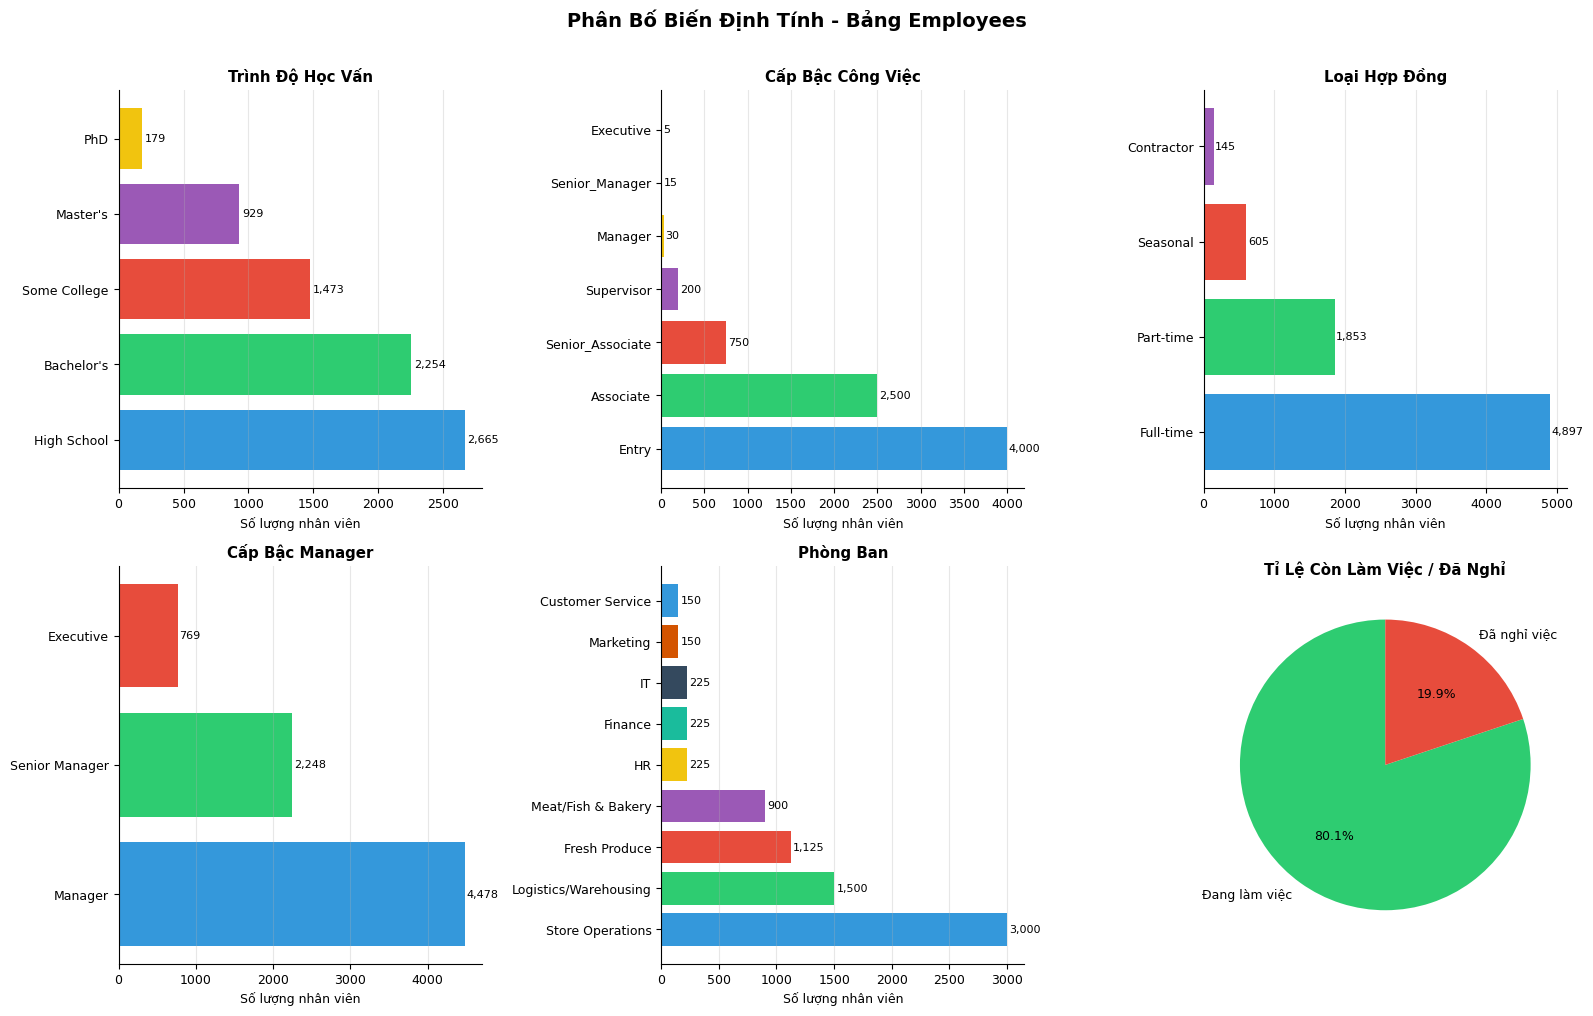

  [Saved] fig1_categorical_distribution.png


<Figure size 640x480 with 0 Axes>

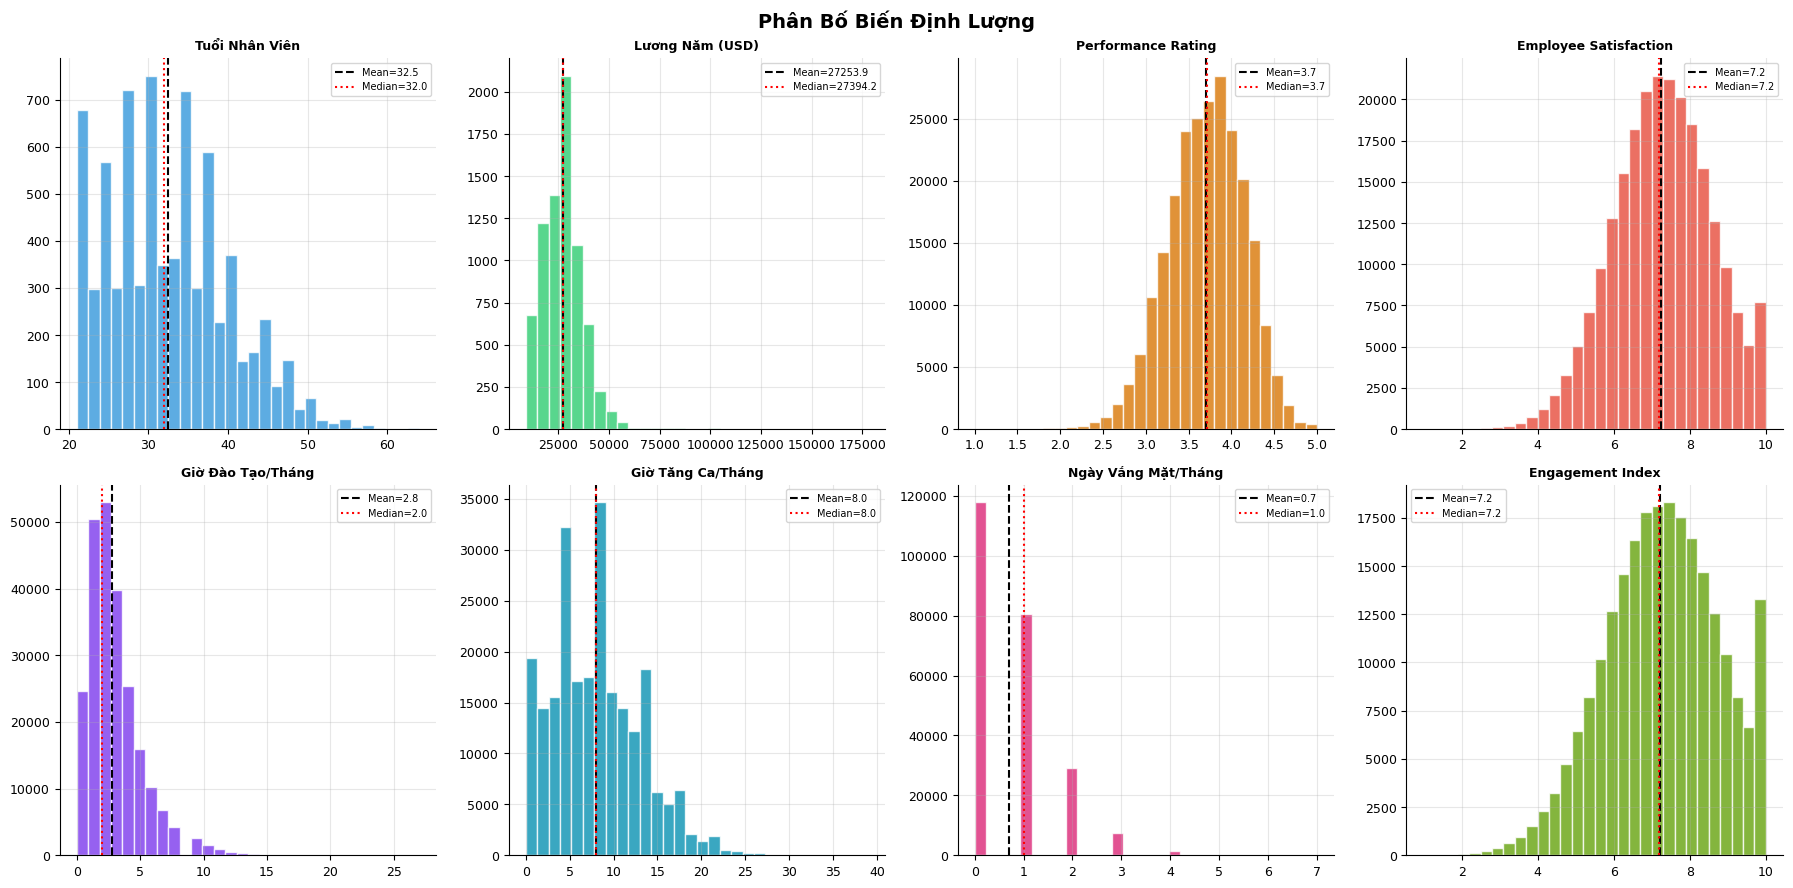

  [Saved] fig2_quantitative_distribution.png


<Figure size 640x480 with 0 Axes>

In [5]:
# PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU
# =============================================================================
print("\n" + "=" * 70)
print("  PHẦN 3: TRỰC QUAN HÓA DỮ LIỆU")
print("=" * 70)

plt.rcParams.update({'font.size': 9, 'font.family': 'DejaVu Sans'})

COLORS = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f1c40f', '#1abc9c', '#34495e', '#d35400']
BLUE  = '#3498db'
GREEN = '#2ecc71'
RED   = '#e74c3c'

PLOTS_DIR = './plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# ── Figure 1: Phân bố biến định tính ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phân Bố Biến Định Tính - Bảng Employees', fontsize=14, fontweight='bold', y=1.01)

cat_plots = [
    ('Education_Level', 'Trình Độ Học Vấn'),
    ('Job_Level',       'Cấp Bậc Công Việc'),
    ('Employment_Type', 'Loại Hợp Đồng'),
    ('Manager_Status',  'Cấp Bậc Manager'),
    ('Department',      'Phòng Ban'),
]
for idx, (col, title) in enumerate(cat_plots):
    ax = axes[idx // 3][idx % 3]
    vc = df_emp[col].value_counts()
    bars = ax.barh(vc.index, vc.values, color=COLORS[:len(vc)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Số lượng nhân viên')
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax = axes[1][2]
active = df_emp['Exit_Date'].isna().sum()
left   = df_emp['Exit_Date'].notna().sum()
ax.pie([active, left], labels=['Đang làm việc', 'Đã nghỉ việc'],
       colors=[GREEN, RED], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 9})
ax.set_title('Tỉ Lệ Còn Làm Việc / Đã Nghỉ', fontweight='bold')

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PLOTS_DIR, 'fig1_categorical_distribution.png'), dpi=150, bbox_inches='tight')
print("  [Saved] fig1_categorical_distribution.png")

# ── Figure 2: Phân bố biến định lượng ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Phân Bố Biến Định Lượng', fontsize=14, fontweight='bold')

quant_data = [
    (df_emp,  'Age',                  'Tuổi Nhân Viên',         BLUE,     'employees'),
    (df_emp,  'Base_Salary_Annual',   'Lương Năm (USD)',         GREEN,    'employees'),
    (df_perf, 'Performance_Rating',   'Performance Rating',      '#D97706','monthly_perf'),
    (df_perf, 'Employee_Satisfaction','Employee Satisfaction',   RED,      'monthly_perf'),
    (df_perf, 'Training_Hours',       'Giờ Đào Tạo/Tháng',      '#7C3AED','monthly_perf'),
    (df_perf, 'Overtime_Hours',       'Giờ Tăng Ca/Tháng',      '#0891B2','monthly_perf'),
    (df_perf, 'Absenteeism_Days',     'Ngày Vắng Mặt/Tháng',    '#DB2777','monthly_perf'),
    (df_perf, 'Engagement_Index',     'Engagement Index',        '#65A30D','monthly_perf'),
]
for idx, (df_src, col, title, color, _) in enumerate(quant_data):
    ax = axes[idx // 4][idx % 4]
    data = df_src[col].dropna()
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1.5, label=f'Median={data.median():.1f}')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PLOTS_DIR, 'fig2_quantitative_distribution.png'), dpi=150, bbox_inches='tight')
print("  [Saved] fig2_quantitative_distribution.png")

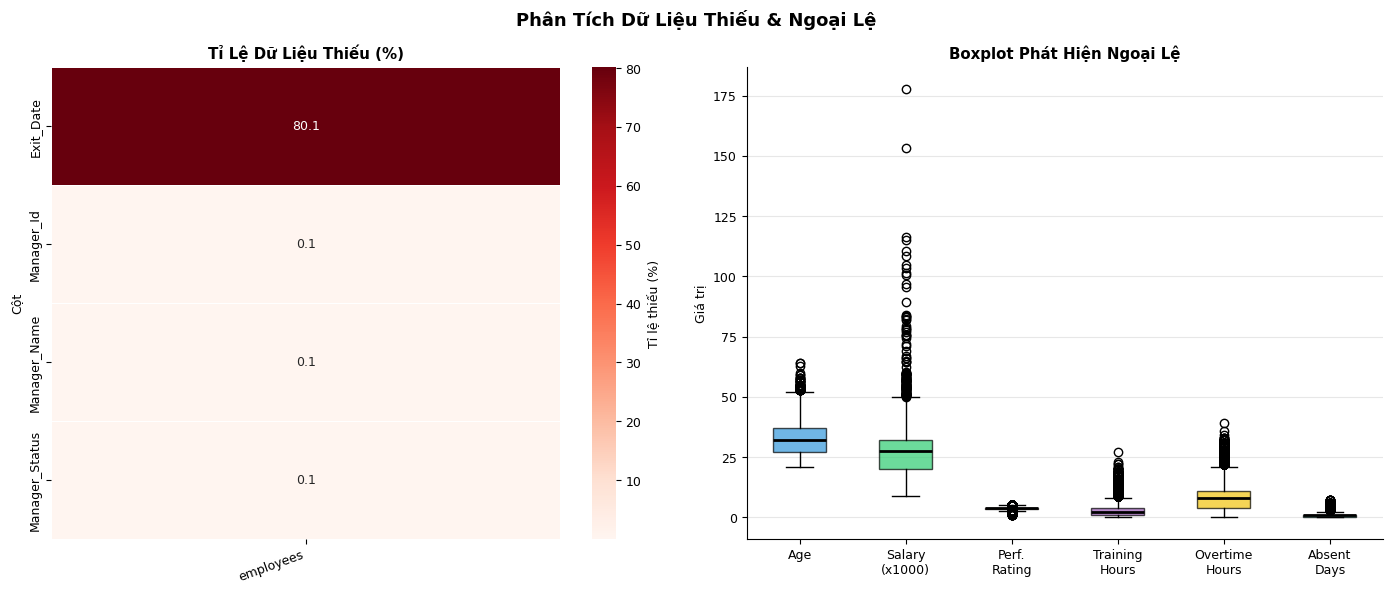

  [Saved] fig3_missing_outliers.png


<Figure size 640x480 with 0 Axes>

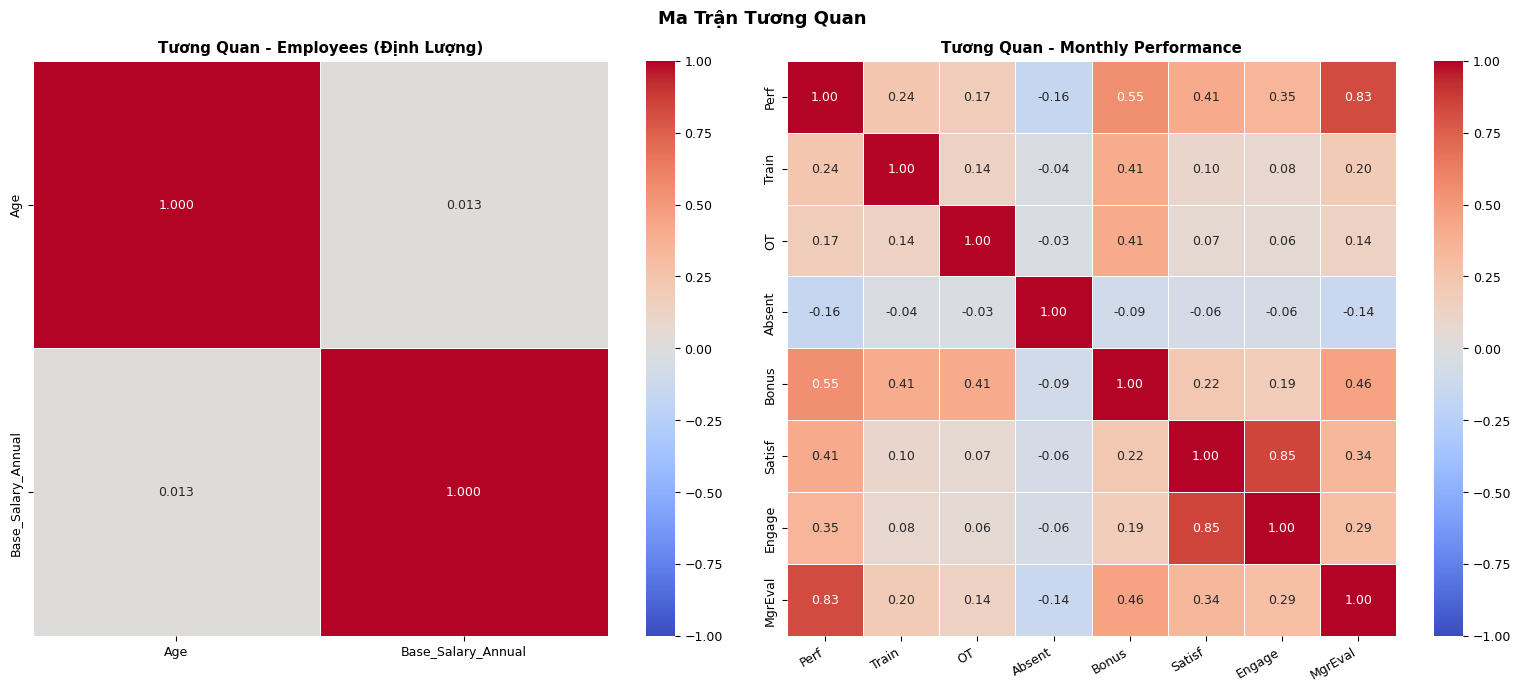

  [Saved] fig4_correlation_matrix.png


<Figure size 640x480 with 0 Axes>

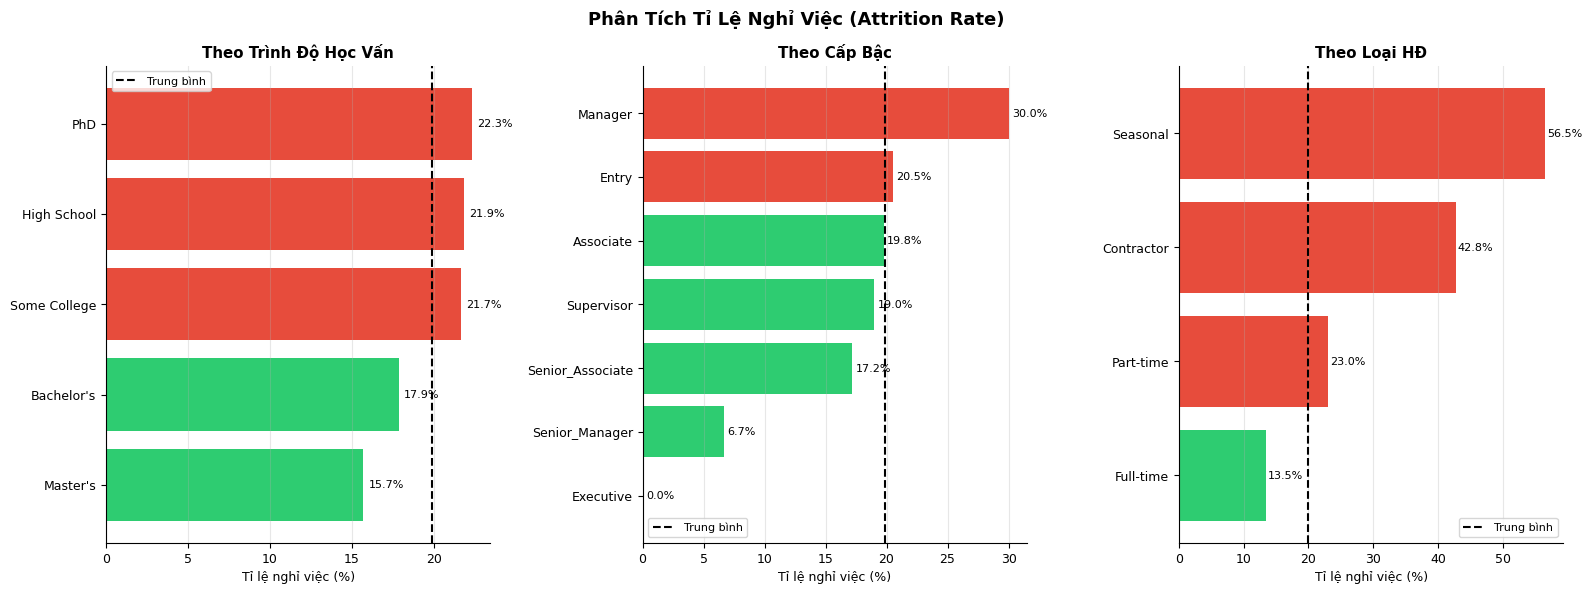

  [Saved] fig5_attrition_analysis.png


<Figure size 640x480 with 0 Axes>

In [6]:
# ── Figure 3: Missing Values & Outliers ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Phân Tích Dữ Liệu Thiếu & Ngoại Lệ', fontsize=13, fontweight='bold')

ax = axes[0]
missing_summary = []
for name, df in sheets.items():
    for col in df.columns:
        pct = df[col].isnull().sum() / len(df) * 100
        if pct > 0:
            missing_summary.append({'Bảng': name, 'Cột': col, 'Tỉ lệ thiếu (%)': pct})

if missing_summary:
    df_miss = pd.DataFrame(missing_summary)
    pivot = df_miss.pivot_table(index='Cột', columns='Bảng', values='Tỉ lệ thiếu (%)', fill_value=0)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax,
                linewidths=0.5, cbar_kws={'label': 'Tỉ lệ thiếu (%)'})
    ax.set_title('Tỉ Lệ Dữ Liệu Thiếu (%)', fontweight='bold')
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
else:
    ax.text(0.5, 0.5, 'Không có dữ liệu thiếu\n(ngoại trừ Exit_Date: 80.12%)',
            ha='center', va='center', fontsize=12, transform=ax.transAxes)
    ax.set_title('Tỉ Lệ Dữ Liệu Thiếu (%)', fontweight='bold')

ax = axes[1]
data_box = [
    df_emp['Age'].dropna(),
    (df_emp['Base_Salary_Annual'] / 1000).dropna(),
    df_perf['Performance_Rating'].dropna(),
    df_perf['Training_Hours'].dropna(),
    df_perf['Overtime_Hours'].dropna(),
    df_perf['Absenteeism_Days'].dropna(),
]
labels_box = ['Age', 'Salary\n(x1000)', 'Perf.\nRating', 'Training\nHours', 'Overtime\nHours', 'Absent\nDays']
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True, notch=False,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, color in zip(bp['boxes'], COLORS[:len(data_box)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplot Phát Hiện Ngoại Lệ', fontweight='bold')
ax.set_ylabel('Giá trị')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PLOTS_DIR, 'fig3_missing_outliers.png'), dpi=150, bbox_inches='tight')
print("  [Saved] fig3_missing_outliers.png")

# ── Figure 4: Ma trận tương quan ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Ma Trận Tương Quan', fontsize=13, fontweight='bold')

corr_emp = df_emp[['Age', 'Base_Salary_Annual']].corr()
sns.heatmap(corr_emp, annot=True, fmt='.3f', cmap='coolwarm', ax=axes[0],
            vmin=-1, vmax=1, linewidths=0.5, square=True)
axes[0].set_title('Tương Quan - Employees (Định Lượng)', fontweight='bold')

corr_perf = df_perf[['Performance_Rating', 'Training_Hours', 'Overtime_Hours',
                      'Absenteeism_Days', 'Monthly_Bonus', 'Employee_Satisfaction',
                      'Engagement_Index', 'Manager_Evaluation']].corr()
sns.heatmap(corr_perf, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=['Perf','Train','OT','Absent','Bonus','Satisf','Engage','MgrEval'],
            yticklabels=['Perf','Train','OT','Absent','Bonus','Satisf','Engage','MgrEval'])
axes[1].set_title('Tương Quan - Monthly Performance', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PLOTS_DIR, 'fig4_correlation_matrix.png'), dpi=150, bbox_inches='tight')
print("  [Saved] fig4_correlation_matrix.png")

# ── Figure 5: Attrition Analysis ───────────────────────────────
df_emp['Is_Active'] = df_emp['Exit_Date'].isna()
df_emp['Attrition'] = ~df_emp['Is_Active']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Phân Tích Tỉ Lệ Nghỉ Việc (Attrition Rate)', fontsize=13, fontweight='bold')

for ax, col, title in zip(axes,
    ['Education_Level', 'Job_Level', 'Employment_Type'],
    ['Theo Trình Độ Học Vấn', 'Theo Cấp Bậc', 'Theo Loại HĐ']):
    att_rate = df_emp.groupby(col)['Attrition'].mean() * 100
    att_rate = att_rate.sort_values(ascending=True)
    bars = ax.barh(att_rate.index, att_rate.values,
                   color=[RED if v > 20 else GREEN for v in att_rate.values])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Tỉ lệ nghỉ việc (%)')
    ax.axvline(df_emp['Attrition'].mean() * 100, color='black',
               linestyle='--', linewidth=1.5, label='Trung bình')
    for bar, val in zip(bars, att_rate.values):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
plt.savefig(os.path.join(PLOTS_DIR, 'fig5_attrition_analysis.png'), dpi=150, bbox_inches='tight')
print("  [Saved] fig5_attrition_analysis.png")

In [7]:
# PHẦN 4: TIỀN XỬ LÝ DỮ LIỆU
# =============================================================================
print("\n" + "=" * 70)
print("  PHẦN 4: TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 70)

df_processed = df_emp.copy()

# ---------------------------------------------------------------
# 4.1 Xử lý kiểu dữ liệu ngày tháng
# ---------------------------------------------------------------
print("\n[4.1] XỬ LÝ KIỂU DỮ LIỆU NGÀY THÁNG...")
df_processed['Hire_Date'] = pd.to_datetime(df_processed['Hire_Date'], dayfirst=True, errors='coerce')
df_processed['Exit_Date'] = pd.to_datetime(df_processed['Exit_Date'], dayfirst=True, errors='coerce')
print(f"  Hire_Date: {df_processed['Hire_Date'].dtype}")
print(f"  Exit_Date: {df_processed['Exit_Date'].dtype}")

# ---------------------------------------------------------------
# 4.2 Tạo cột phái sinh
# ---------------------------------------------------------------
print("\n[4.2] TẠO CỘT PHÁI SINH (FEATURE ENGINEERING)...")
reference_date = pd.Timestamp('2024-12-31')

df_processed['Tenure_Years'] = df_processed.apply(
    lambda r: (r['Exit_Date'] - r['Hire_Date']).days / 365
    if pd.notna(r['Exit_Date'])
    else (reference_date - r['Hire_Date']).days / 365,
    axis=1
).round(2)

df_processed['Still_Active'] = df_processed['Exit_Date'].isna().astype(int)
print(f"  + Tenure_Years : thâm niên làm việc (năm)")
print(f"  + Still_Active : 1=đang làm, 0=đã nghỉ")
print(f"\n  Thống kê Tenure_Years:")
print(df_processed['Tenure_Years'].describe().round(2))

# ---------------------------------------------------------------
# 4.3 Xử lý giá trị thiếu
# ---------------------------------------------------------------
print("\n[4.3] XỬ LÝ GIÁ TRỊ THIẾU...")
print(f"  Manager_Id missing trước: {df_processed['Manager_Id'].isna().sum()}")
df_processed['Manager_Id']     = df_processed['Manager_Id'].fillna('UNKNOWN')
df_processed['Manager_Name']   = df_processed['Manager_Name'].fillna('Unknown')
df_processed['Manager_Status'] = df_processed['Manager_Status'].fillna('Unknown')
print(f"  Manager_Id missing sau : {df_processed['Manager_Id'].isna().sum()}")

# ---------------------------------------------------------------
# 4.4 Tổng hợp monthly_performance theo Employee_Id
# ---------------------------------------------------------------
print("\n[4.4] TỔNG HỢP DỮ LIỆU MONTHLY_PERFORMANCE...")
df_perf_temp = df_perf.copy()
df_perf_temp['Year_Month'] = pd.to_datetime(df_perf_temp['Year_Month'])

perf_numeric_cols = [
    'Performance_Rating', 'Training_Hours', 'Overtime_Hours',
    'Absenteeism_Days', 'Monthly_Bonus', 'Benefits_Cost',
    'Employee_Satisfaction', 'Engagement_Index', 'Manager_Evaluation'
]

df_perf_agg = df_perf_temp.groupby('Employee_Id')[perf_numeric_cols].mean().reset_index()
df_perf_agg.columns = ['Employee_Id'] + [col + '_Avg' for col in perf_numeric_cols]
print(f"  Shape df_perf_agg: {df_perf_agg.shape}")

# Gộp vào df_processed
df_processed = pd.merge(df_processed, df_perf_agg, on='Employee_Id', how='left')
print(f"  Shape sau merge: {df_processed.shape}")

# ---------------------------------------------------------------
# 4.5 TẠO NHÃN HIỆU SUẤT từ Performance_Rating_Avg (KHÔNG data leakage)
# ---------------------------------------------------------------
print("\n[4.5] TẠO NHÃN HIỆU SUẤT TỪ Performance_Rating_Avg...")
print("  → Dùng trực tiếp điểm đánh giá thực tế thay vì điểm tổng hợp thủ công")

# Điền NaN cho nhân viên không có dữ liệu monthly (dùng median)
median_rating = df_processed['Performance_Rating_Avg'].median()
df_processed['Performance_Rating_Avg'] = df_processed['Performance_Rating_Avg'].fillna(median_rating)
print(f"  Median Performance_Rating_Avg: {median_rating:.2f}  (dùng để điền {df_processed['Performance_Rating_Avg'].isna().sum()} NaN)")

# Chia 3 nhóm bằng nhau theo phân vị
q33 = df_processed['Performance_Rating_Avg'].quantile(0.33)
q66 = df_processed['Performance_Rating_Avg'].quantile(0.66)

df_processed['Performance'] = pd.cut(
    df_processed['Performance_Rating_Avg'],
    bins=[-np.inf, q33, q66, np.inf],
    labels=['Low', 'Medium', 'High']
).astype(str)

print(f"  Ngưỡng phân loại: Low ≤ {q33:.2f} < Medium ≤ {q66:.2f} < High")
print("\n  Phân bố nhãn hiệu suất:")
dist = df_processed['Performance'].value_counts()
for label, count in dist.items():
    print(f"    {label:8s}: {count:5,}  ({count/len(df_processed)*100:.1f}%)")

# ---------------------------------------------------------------
# 4.6 Loại bỏ các cột không cần thiết
# ---------------------------------------------------------------
print("\n[4.6] LOẠI BỎ CÁC CỘT KHÔNG CẦN THIẾT...")
drop_cols = ['Full_Name', 'Manager_Name', 'Hire_Date', 'Exit_Date',
             'Store_Location_Latitude', 'Store_Location_Longitude']
df_model = df_processed.drop(columns=[c for c in drop_cols if c in df_processed.columns])
print(f"  Đã loại bỏ: {drop_cols}")
print(f"  Số cột còn lại: {df_model.shape[1]}")


  PHẦN 4: TIỀN XỬ LÝ DỮ LIỆU

[4.1] XỬ LÝ KIỂU DỮ LIỆU NGÀY THÁNG...
  Hire_Date: datetime64[ns]
  Exit_Date: datetime64[ns]

[4.2] TẠO CỘT PHÁI SINH (FEATURE ENGINEERING)...
  + Tenure_Years : thâm niên làm việc (năm)
  + Still_Active : 1=đang làm, 0=đã nghỉ

  Thống kê Tenure_Years:
count    7500.00
mean        4.71
std         2.29
min         0.25
25%         3.33
50%         4.20
75%         5.68
max        13.00
Name: Tenure_Years, dtype: float64

[4.3] XỬ LÝ GIÁ TRỊ THIẾU...
  Manager_Id missing trước: 5
  Manager_Id missing sau : 0

[4.4] TỔNG HỢP DỮ LIỆU MONTHLY_PERFORMANCE...
  Shape df_perf_agg: (7086, 10)
  Shape sau merge: (7500, 31)

[4.5] TẠO NHÃN HIỆU SUẤT TỪ Performance_Rating_Avg...
  → Dùng trực tiếp điểm đánh giá thực tế thay vì điểm tổng hợp thủ công
  Median Performance_Rating_Avg: 3.66  (dùng để điền 0 NaN)
  Ngưỡng phân loại: Low ≤ 3.53 < Medium ≤ 3.83 < High

  Phân bố nhãn hiệu suất:
    High    : 2,550  (34.0%)
    Low     : 2,476  (33.0%)
    Medium  : 2,47

In [8]:
df_model.head()

,Employee_Id,Age,Education_Level,Department,Job_Role,Job_Level,Employment_Type,Base_Salary_Annual,Store_Location,Store_Id,...,Performance_Rating_Avg,Training_Hours_Avg,Overtime_Hours_Avg,Absenteeism_Days_Avg,Monthly_Bonus_Avg,Benefits_Cost_Avg,Employee_Satisfaction_Avg,Engagement_Index_Avg,Manager_Evaluation_Avg,Performance
0,EMP000001,23,Master's,Store Operations,Cashier,Entry,Full-time,25745.40,Charlotte,STR058,...,3.960000,4.500000,13.750000,0.500000,705.450000,1727.09,7.725000,7.950000,4.125000,High
1,EMP000002,26,Master's,Store Operations,Sales Associate,Associate,Full-time,39408.57,San Jose,STR137,...,3.972500,4.944444,13.416667,0.722222,718.698056,1584.89,7.469444,7.319444,3.972222,High
2,EMP000003,38,Bachelor's,Store Operations,Cashier,Entry,Full-time,29319.94,Jacksonville,STR008,...,4.165000,5.111111,15.083333,0.833333,747.610833,1584.56,8.086111,7.875000,4.116667,High
3,EMP000004,33,Bachelor's,Store Operations,Senior Sales Associate,Senior_Associate,Full-time,43979.88,Las Vegas,STR063,...,3.982778,5.750000,13.916667,0.611111,808.616667,1759.48,7.338889,7.344444,3.933333,High
4,EMP000005,24,High School,Store Operations,Cashier,Entry,Full-time,23560.19,Chicago,STR109,...,4.075833,1.777778,9.000000,0.444444,279.157778,947.89,7.911111,7.958333,4.025000,High


In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer # Corrected import statement
import warnings
warnings.filterwarnings('ignore')

# PHẦN 5: MÃ HÓA VÀ CHỌN ĐẶC TRƯNG
# =============================================================================
print("\n" + "=" * 70)
print("  PHẦN 5: MÃ HÓA DỮ LIỆU ĐỊNH TÍNH VÀ CHỌN ĐẶC TRƯNG")
print("=" * 70)

# Explicitly initialize df_model from df_processed to ensure all columns are present.
# Then apply the column drops from section 4.6
df_model = df_processed.copy()
drop_cols_4_6 = ['Full_Name', 'Manager_Name', 'Hire_Date', 'Exit_Date',
                 'Store_Location_Latitude', 'Store_Location_Longitude']
df_model.drop(columns=[c for c in drop_cols_4_6 if c in df_model.columns], inplace=True)
print(f"  [Re-initialized df_model from df_processed and dropped Section 4.6 columns]. Số cột còn lại: {df_model.shape[1]}")

# ---------------------------------------------------------------
# 5.1 Ordinal Encoding
# ---------------------------------------------------------------
print("\n[5.1] ORDINAL ENCODING (Manager_Status):")

mgr_order = {
    'Unknown': 0,
    'Manager': 1,
    'Senior Manager': 2,
    'Executive': 3
}

# Ensure 'Manager_Status' column exists before mapping
if 'Manager_Status' in df_model.columns:
    df_model['Manager_Status_Enc'] = (
        df_model['Manager_Status']
        .fillna('Unknown')
        .map(mgr_order)
    )
    print(f"  Manager_Status: {mgr_order}")
else:
    print("  'Manager_Status' column not found, skipping ordinal encoding.")
    # If Manager_Status is not found, create the _Enc column with a default value to prevent downstream errors
    df_model['Manager_Status_Enc'] = 0 # Default to 'Unknown'

# ---------------------------------------------------------------
# 5.2 Label Encoding
# ---------------------------------------------------------------
print("\n[5.2] LABEL ENCODING (biến danh nghĩa):")

features_cat_base = [
    'Education_Level',
    'Department',
    'Employment_Type',
    'Job_Level'
]

le_dict = {}

for col in features_cat_base:
    if col in df_model.columns:
        le = LabelEncoder()

        df_model[col + '_enc'] = le.fit_transform(
            df_model[col].astype(str)
        )

        le_dict[col] = le

        print(
            f"  '{col}' → '{col}_enc' "
            f"({df_model[col].nunique()} giá trị)"
        )
    else:
        print(f"  '{col}' column not found, skipping label encoding.")
        # Create a placeholder column to avoid KeyErrors in feature selection
        df_model[col + '_enc'] = 0 # Default value

# ---------------------------------------------------------------
# 5.3 Loại bỏ cột không sử dụng
# ---------------------------------------------------------------
print("\n[5.3] LOẠI BỎ CỘT KHÔNG SỬ DỤNG:")

drop_cols_enc = [
    'Education_Level',
    'Department',
    'Employment_Type',
    'Job_Level',
    'Manager_Status',
    'Store_Id',
    'Manager_Id',
    'Job_Role',
    'Store_Location',
    'Is_Active',
    'Still_Active',
    'Attrition'
]

df_model.drop(
    columns=[c for c in drop_cols_enc if c in df_model.columns],
    inplace=True
)

print(f"  Số cột còn lại: {df_model.shape[1]}")

# ---------------------------------------------------------------
# 5.4 Chọn đặc trưng cuối cùng
# ---------------------------------------------------------------
print("\n[5.4] CHỌN ĐẶC TRƯNG CUỐI CÙNG:")

features_num = [
    'Age',
    'Tenure_Years'
]

features_enc = [
    'Education_Level_enc',
    'Employment_Type_enc',
    'Job_Level_enc'
]

perf_features = [
    'Training_Hours_Avg',
    'Overtime_Hours_Avg',
    'Absenteeism_Days_Avg',
    'Monthly_Bonus_Avg',
    'Benefits_Cost_Avg',
    'Employee_Satisfaction_Avg',
    'Engagement_Index_Avg',
    'Manager_Evaluation_Avg'
]

all_features = [
    c for c in (
        features_num + features_enc + perf_features
    )
    if c in df_model.columns
]

print(
    f"  Đặc trưng sử dụng "
    f"({len(all_features)} cột)"
)

X = df_model[all_features].copy()
y = df_model['Performance'].copy()

# ---------------------------------------------------------------
# 5.5 Impute NaN bằng SimpleImputer (tránh data leakage)
# ---------------------------------------------------------------
print("\n[5.5] IMPUTE NaN bằng SimpleImputer (mean):")
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=all_features)

nan_count = X.isnull().sum().sum()
print(f"  NaN còn lại sau impute: {nan_count}")

# ---------------------------------------------------------------
# 5.6 Encode nhãn
# ---------------------------------------------------------------
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

print("\n[5.6] NHÃN MỤC TIÊU:")
print(f"  Classes: {list(le_target.classes_)}")
print(f"  Tổng mẫu: {len(X):,}")

# Lưu lại để dùng cho các mô hình phía sau
print(f"\n✓ X shape: {X.shape}")
print(f"✓ y shape: {y_enc.shape}")


  PHẦN 5: MÃ HÓA DỮ LIỆU ĐỊNH TÍNH VÀ CHỌN ĐẶC TRƯNG
  [Re-initialized df_model from df_processed and dropped Section 4.6 columns]. Số cột còn lại: 26

[5.1] ORDINAL ENCODING (Manager_Status):
  Manager_Status: {'Unknown': 0, 'Manager': 1, 'Senior Manager': 2, 'Executive': 3}

[5.2] LABEL ENCODING (biến danh nghĩa):
  'Education_Level' → 'Education_Level_enc' (5 giá trị)
  'Department' → 'Department_enc' (9 giá trị)
  'Employment_Type' → 'Employment_Type_enc' (4 giá trị)
  'Job_Level' → 'Job_Level_enc' (7 giá trị)

[5.3] LOẠI BỎ CỘT KHÔNG SỬ DỤNG:
  Số cột còn lại: 19

[5.4] CHỌN ĐẶC TRƯNG CUỐI CÙNG:
  Đặc trưng sử dụng (13 cột)

[5.5] IMPUTE NaN bằng SimpleImputer (mean):
  NaN còn lại sau impute: 0

[5.6] NHÃN MỤC TIÊU:
  Classes: ['High', 'Low', 'Medium']
  Tổng mẫu: 7,500

✓ X shape: (7500, 13)
✓ y shape: (7500,)



  PHẦN 6: XÂY DỰNG MÔ HÌNH GAUSSIAN NAÏVE BAYES

[6.1] Train: 6,000 mẫu | Test: 1,500 mẫu

[6.2] Huấn luyện Gaussian Naïve Bayes...
  Accuracy: 0.8787 (87.87%)

[6.3] Báo cáo phân loại:
-------------------------------------------------------
              precision    recall  f1-score   support

        High       0.96      0.86      0.91       510
         Low       0.89      0.92      0.90       495
      Medium       0.80      0.85      0.83       495

    accuracy                           0.88      1500
   macro avg       0.88      0.88      0.88      1500
weighted avg       0.88      0.88      0.88      1500

  Cross-Validation (5-fold): 0.8800 ± 0.0046
  AUC-ROC (macro OvR):       0.9710

[6.4] Vẽ biểu đồ kết quả...


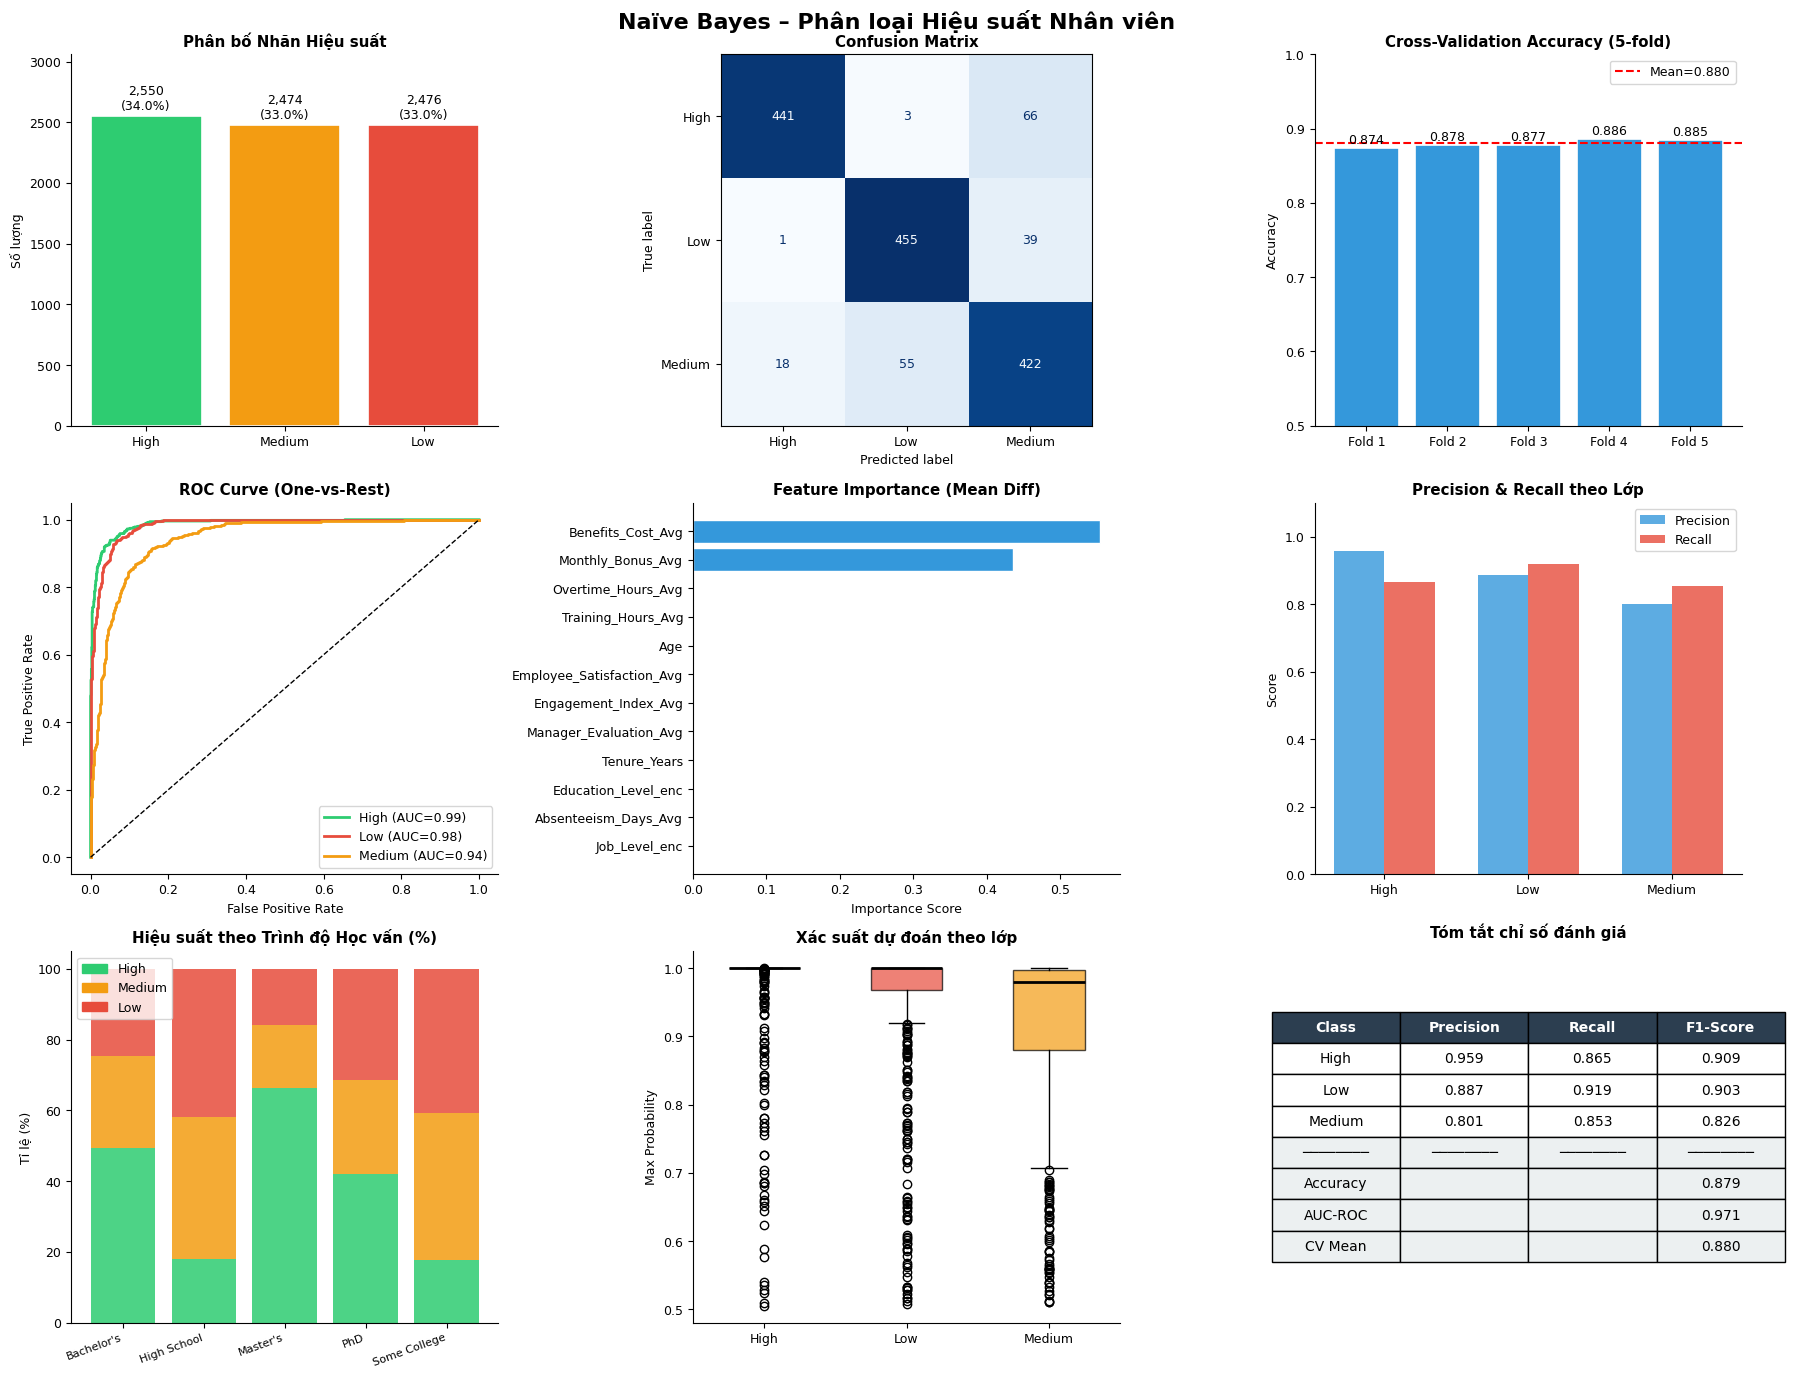


[6.5] Đã lưu biểu đồ: /content/outputs/naive_bayes_results.png


In [10]:
# PHẦN 6: XÂY DỰNG MÔ HÌNH GAUSSIAN NAÏVE BAYES
# =============================================================================
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

print("\n" + "=" * 70)
print("  PHẦN 6: XÂY DỰNG MÔ HÌNH GAUSSIAN NAÏVE BAYES")
print("=" * 70)

# ── 6.1 Chia tập train/test ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"\n[6.1] Train: {len(X_train):,} mẫu | Test: {len(X_test):,} mẫu")

# ── 6.2 Huấn luyện ────────────────────────────────────────────
print("\n[6.2] Huấn luyện Gaussian Naïve Bayes...")
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"  Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ── 6.3 Đánh giá ──────────────────────────────────────────────
print("\n[6.3] Báo cáo phân loại:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gnb, X, y_enc, cv=cv, scoring='accuracy')
print(f"  Cross-Validation (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f"  AUC-ROC (macro OvR):       {auc:.4f}")

# ── 6.4 Trực quan hóa kết quả ─────────────────────────────────
print("\n[6.4] Vẽ biểu đồ kết quả...")

class_colors = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
class_order  = ['High', 'Medium', 'Low']

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Naïve Bayes – Phân loại Hiệu suất Nhân viên",
             fontsize=16, fontweight='bold', y=0.98)

# (a) Phân bố nhãn
ax1 = fig.add_subplot(3, 3, 1)
counts = [dist.get(c, 0) for c in class_order]
bars = ax1.bar(class_order, counts,
               color=[class_colors[c] for c in class_order],
               edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{cnt:,}\n({cnt/len(df_model)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)
ax1.set_title('Phân bố Nhãn Hiệu suất', fontweight='bold')
ax1.set_ylabel('Số lượng')
ax1.set_ylim(0, max(counts) * 1.2)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# (b) Confusion Matrix
ax2 = fig.add_subplot(3, 3, 2)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=ax2, colorbar=False, cmap='Blues')
ax2.set_title('Confusion Matrix', fontweight='bold')

# (c) Cross-Validation scores
ax3 = fig.add_subplot(3, 3, 3)
fold_labels = [f'Fold {i+1}' for i in range(5)]
bar_cv = ax3.bar(fold_labels, cv_scores, color='#3498db', edgecolor='white', linewidth=1.2)
ax3.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean={cv_scores.mean():.3f}')
for bar, score in zip(bar_cv, cv_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)
ax3.set_title('Cross-Validation Accuracy (5-fold)', fontweight='bold')
ax3.set_ylabel('Accuracy')
ax3.set_ylim(0.5, 1.0)
ax3.legend(fontsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# (d) ROC Curve (OvR)
ax4 = fig.add_subplot(3, 3, 4)
for i, cls in enumerate(le_target.classes_):
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
    auc_cls = roc_auc_score((y_test == i).astype(int), y_prob[:, i])
    ax4.plot(fpr, tpr, label=f'{cls} (AUC={auc_cls:.2f})',
             color=class_colors[cls], linewidth=2)
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax4.set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.legend(fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# (e) Feature Importance (log-variance proxy)
ax5 = fig.add_subplot(3, 3, 5)
feat_importance = np.abs(gnb.theta_[0] - gnb.theta_[1]) + np.abs(gnb.theta_[1] - gnb.theta_[2])
feat_importance = feat_importance / feat_importance.sum()
feat_df = pd.DataFrame({'Feature': all_features, 'Importance': feat_importance})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(12)
ax5.barh(feat_df['Feature'], feat_df['Importance'], color='#3498db', edgecolor='white')
ax5.set_title('Feature Importance (Mean Diff)', fontweight='bold')
ax5.set_xlabel('Importance Score')
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# (f) Precision-Recall per class
ax6 = fig.add_subplot(3, 3, 6)
from sklearn.metrics import precision_score, recall_score, f1_score
classes = le_target.classes_
precision = precision_score(y_test, y_pred, average=None)
recall    = recall_score(y_test, y_pred, average=None)
x = np.arange(len(classes))
w = 0.35
ax6.bar(x - w/2, precision, w, label='Precision', color='#3498db', alpha=0.8)
ax6.bar(x + w/2, recall,    w, label='Recall',    color='#e74c3c', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(classes)
ax6.set_title('Precision & Recall theo Lớp', fontweight='bold')
ax6.set_ylabel('Score')
ax6.set_ylim(0, 1.1)
ax6.legend(fontsize=9)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

# (g) Hiệu suất theo Education Level
ax7 = fig.add_subplot(3, 3, 7)
df_plot = df_model[['Education_Level_enc', 'Performance']].copy()
df_plot['Education_Level_enc'] = le_dict['Education_Level'].inverse_transform(df_plot['Education_Level_enc'])
edu_perf = df_plot.groupby(['Education_Level_enc', 'Performance']).size().unstack(fill_value=0)
edu_perf_pct = edu_perf.div(edu_perf.sum(axis=1), axis=0) * 100
edu_order = edu_perf_pct.index.tolist()
bottom = np.zeros(len(edu_order))
patches = []
for cls, color in class_colors.items():
    if cls in edu_perf_pct.columns:
        vals = edu_perf_pct[cls].values
        ax7.bar(range(len(edu_order)), vals, bottom=bottom, color=color, alpha=0.85, label=cls)
        bottom += vals
        patches.append(mpatches.Patch(color=color, label=cls))
ax7.set_xticks(range(len(edu_order)))
ax7.set_xticklabels(edu_order, rotation=20, ha='right', fontsize=8)
ax7.set_title('Hiệu suất theo Trình độ Học vấn (%)', fontweight='bold')
ax7.set_ylabel('Tỉ lệ (%)')
ax7.legend(handles=patches, fontsize=9, loc='upper left')
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)

# (h) Probability Distribution (Boxplot)
ax8 = fig.add_subplot(3, 3, 8)
pred_labels = le_target.inverse_transform(y_pred)
for i, cls in enumerate(le_target.classes_):
    mask = pred_labels == cls
    if mask.sum() > 0:
        prob_max = y_prob[mask].max(axis=1)
        ax8.boxplot(prob_max, positions=[i], widths=0.5,
                    patch_artist=True,
                    boxprops=dict(facecolor=class_colors[cls], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
ax8.set_xticks(range(len(le_target.classes_)))
ax8.set_xticklabels(le_target.classes_)
ax8.set_title('Xác suất dự đoán theo lớp', fontweight='bold')
ax8.set_ylabel('Max Probability')
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)

# (i) Bảng tóm tắt chỉ số
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')
rows = []
for cls in le_target.classes_:
    i = list(le_target.classes_).index(cls)
    mask_true = (y_test == i)
    mask_pred = (y_pred == i)
    tp = (mask_true & mask_pred).sum()
    fp = (~mask_true & mask_pred).sum()
    fn = (mask_true & ~mask_pred).sum()
    prec = tp/(tp+fp) if (tp+fp) > 0 else 0
    rec  = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    rows.append([cls, f'{prec:.3f}', f'{rec:.3f}', f'{f1:.3f}'])

table_data = rows + [['─'*8]*4,
                     ['Accuracy', '', '', f'{acc:.3f}'],
                     ['AUC-ROC',  '', '', f'{auc:.3f}'],
                     ['CV Mean',  '', '', f'{cv_scores.mean():.3f}']]
col_labels = ['Class', 'Precision', 'Recall', 'F1-Score']
tbl = ax9.table(cellText=table_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif r in [len(rows)+1, len(rows)+2, len(rows)+3, len(rows)+4]:
        cell.set_facecolor('#ecf0f1')
ax9.set_title('Tóm tắt chỉ số đánh giá', fontweight='bold', pad=10)

plt.tight_layout()

output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'naive_bayes_results.png')
plt.savefig(output_path, bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print(f"\n[6.5] Đã lưu biểu đồ: {output_path}")

In [14]:
# =============================================================================
# 6.6 IN KẾT QUẢ DỰ ĐOÁN THEO NHÂN VIÊN
# =============================================================================
print("\n" + "=" * 70)
print("  PHẦN 6.6: KẾT QUẢ THỰC TẾ VS DỰ ĐOÁN")
print("=" * 70)

# Chia lại để lấy index tương ứng với tập test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# Lấy Employee_ID theo index của tập test
employee_ids_test = df_processed.loc[X_test.index, 'Employee_Id']

# Chuyển nhãn số về nhãn gốc
actual_labels = le_target.inverse_transform(y_test)
predicted_labels = le_target.inverse_transform(y_pred)

# Tạo bảng kết quả
df_results = pd.DataFrame({
    'Employee_Id': employee_ids_test.values,
    'actual': actual_labels,
    'predicted': predicted_labels
})

print(df_results.to_string(index=False))


  PHẦN 6.6: KẾT QUẢ THỰC TẾ VS DỰ ĐOÁN
Employee_Id actual predicted
  EMP004939    Low    Medium
  EMP005802 Medium    Medium
  EMP000923   High      High
  EMP003619 Medium       Low
  EMP001118   High      High
  EMP001221 Medium    Medium
  EMP003682    Low       Low
  EMP001757   High    Medium
  EMP002612    Low       Low
  EMP007108    Low       Low
  EMP003574 Medium       Low
  EMP001831 Medium    Medium
  EMP002064   High    Medium
  EMP005651 Medium    Medium
  EMP000708 Medium    Medium
  EMP001948    Low       Low
  EMP000821   High      High
  EMP002640 Medium    Medium
  EMP001428 Medium    Medium
  EMP002345   High      High
  EMP000667   High      High
  EMP002508 Medium    Medium
  EMP002114 Medium    Medium
  EMP001326 Medium    Medium
  EMP001809   High      High
  EMP001602    Low       Low
  EMP007190 Medium    Medium
  EMP004913 Medium    Medium
  EMP002800   High      High
  EMP007270   High      High
  EMP003660 Medium    Medium
  EMP001933 Medium    Medium
  E

In [15]:
# PHẦN 7: VÍ DỤ DỰ ĐOÁN NHÂN VIÊN MỚI
# =============================================================================
print("\n" + "=" * 60)
print("  PHẦN 7: VÍ DỤ DỰ ĐOÁN NHÂN VIÊN MỚI")
print("=" * 60)

sample_data = {
    'Age':                     [28,    45,    35],
    'Base_Salary_Annual':      [35000, 90000, 55000],
    'Tenure_Years':            [1.5,   12.0,  4.5],
    'Overtime_Hours_Avg':      [10.0,  15.0,  8.0],
    'Absenteeism_Days_Avg':    [2.0,   1.0,   3.0],
    'Manager_Evaluation_Avg':  [4.0,   4.5,   3.5],
    'Benefits_Cost_Avg':       [500,   800,   400],
    'Employee_Satisfaction_Avg': [4.0, 4.5,   3.5],
    'Engagement_Index_Avg':    [7.0,   8.5,   6.0],
    'Monthly_Bonus_Avg':       [200,   500,   150],
    'Training_Hours_Avg':      [10,    15,    8],
    'Manager_Status_Enc':      [0,     2,     1],
    'Education_Level_enc':     le_dict['Education_Level'].transform(["Bachelor's", "Master's", "High School"]),
    'Department_enc':          le_dict['Department'].transform(['Store Operations', 'IT', 'Finance']),
    'Employment_Type_enc':     le_dict['Employment_Type'].transform(['Part-time', 'Full-time', 'Full-time']),
    'Job_Level_enc':           le_dict['Job_Level'].transform(['Entry', 'Manager', 'Associate']),
}

sample_df = pd.DataFrame(sample_data)[all_features]

preds = gnb.predict(sample_df)
probs = gnb.predict_proba(sample_df)

profiles = [
    "Nhân viên mới, Entry, Bán lẻ",
    "Nhân viên kỳ cựu, Manager, IT",
    "Nhân viên trung niên, Associate, Tài chính",
]

print("-" * 55)
for i, (profile, pred, prob) in enumerate(zip(profiles, preds, probs), 1):
    label = le_target.inverse_transform([pred])[0]
    prob_pct = {le_target.classes_[j]: f"{prob[j]*100:.1f}%" for j in range(len(le_target.classes_))}
    print(f"  Nhân viên {i} ({profile}):")
    print(f"    → Dự đoán: [{label}]  | Xác suất: {prob_pct}")

print("\n" + "=" * 60)
print("  HOÀN THÀNH! Kết quả đã lưu vào naive_bayes_results.png")
print("=" * 60)


  PHẦN 7: VÍ DỤ DỰ ĐOÁN NHÂN VIÊN MỚI
-------------------------------------------------------
  Nhân viên 1 (Nhân viên mới, Entry, Bán lẻ):
    → Dự đoán: [Low]  | Xác suất: {'High': '1.7%', 'Low': '98.3%', 'Medium': '0.0%'}
  Nhân viên 2 (Nhân viên kỳ cựu, Manager, IT):
    → Dự đoán: [High]  | Xác suất: {'High': '100.0%', 'Low': '0.0%', 'Medium': '0.0%'}
  Nhân viên 3 (Nhân viên trung niên, Associate, Tài chính):
    → Dự đoán: [Low]  | Xác suất: {'High': '0.0%', 'Low': '100.0%', 'Medium': '0.0%'}

  HOÀN THÀNH! Kết quả đã lưu vào naive_bayes_results.png
